# Quality assessment for spatial gene expression imputation and uncertainty calibration

Borrows heavily from code from the TISSUE Github: https://github.com/sunericd/TISSUE and https://github.com/sunericd/tissue-figures-and-analyses

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import scanpy as sc
from scipy.stats import pearsonr, spearmanr
import anndata as ad
import seaborn as sns
import pickle
import os

os.chdir("/labs/abrunet1/Eric/MERFISH/results/for_imputation/")

from TISSUE.tissue.main import *
from TISSUE.tissue.utils import *
from TISSUE.tissue.experiments import measure_calibration_error

In [4]:
#### Swap dataset names to real identifiers
dataset_mapper = {"SVZ": "Buckley et al. (2023)"}

method_mapper = {"tangram": "Tangram",
                 "spage": "SpaGE",
                 "knn": "Harmony",
                 "gimvi": "gimVI"}
#### 

# SpaGE prediction performance

In [5]:
datasets = ["SVZ"]
methods = ['spage']

dataset_col = []
method_col = []
R_col = []
Spearman_col = []
MAE_col = []

# loop through datasets
for d in datasets:
    
    # read results
    adata = sc.read_h5ad("SCPI_k4_k1/"+d+"_knn_spage_tangram_SCPI.h5ad")
    
    # get dimensions
    n_cells = adata.shape[0]
    n_genes = adata.shape[1]
    
    # loop through each prediction model
    for method in methods:
        
        # get predicted and actual expression
        imputed = np.array(adata.obsm[method+"_predicted_expression"])
        actual = adata[:,adata.obsm[method+"_predicted_expression"].columns].X
        
        # compute statistics for each gene in the dataset
        for j in range(adata.obsm[method+"_predicted_expression"].shape[1]):
            not_nans = (~np.isnan(imputed[:,j]) & ~np.isnan(actual[:,j]))
            
            # compute stats
            r, p = pearsonr(imputed[not_nans,j], actual[not_nans,j])
            rho, p = spearmanr(imputed[:,j], actual[:,j])
            mae = np.nanmean(np.abs(imputed[:,j]-actual[:,j]))
            
            name = dataset_mapper[d]
            
            # append results
            #dataset_col.append(name+f"\nn={n_cells}\np={n_genes}") # add n_cell/n_gene info
            dataset_col.append(name)
            method_col.append(method_mapper[method])
            R_col.append(r)
            Spearman_col.append(rho)
            MAE_col.append(mae)

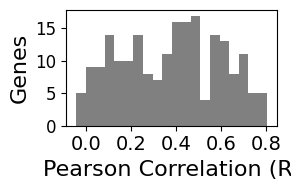

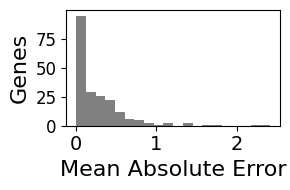

In [6]:
# compile into dataframe for plotting
df = pd.DataFrame([])
df["Dataset"] = dataset_col
df["Method"] = method_col
df["Pearson"] = R_col
df["Spearman"] = Spearman_col
df["MAE"] = MAE_col
df["MAE"] = df["MAE"].astype(float)
df["log MAE"] = np.log(df["MAE"])


# Pearson
plt.figure(figsize=(3,2))
#sns.violinplot(x="Dataset", y="Pearson", color="0.8", data=df)
plt.hist(df[df["Method"]=="SpaGE"]["Pearson"], bins=20, facecolor='0.5')
plt.ylabel("Genes", fontsize=16)
plt.xlabel("Pearson Correlation (R)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
#plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig('../../plots/mechanism/SpaGE_histo_Pearson.pdf', dpi=300, bbox_inches='tight')
plt.show()

# MAE
plt.figure(figsize=(3,2))
plt.hist(df[df["Method"]=="SpaGE"]["MAE"], bins=20, facecolor='0.5')
plt.ylabel("Genes", fontsize=16)
plt.xlabel("Mean Absolute Error", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)
#plt.legend([],[], frameon=False)
plt.tight_layout()
plt.savefig('../../plots/mechanism/SpaGE_histo_MAE.pdf', dpi=300, bbox_inches='tight')
plt.show()

# TISSUE calibration performance

In [34]:
# CELL x GENE level

pi_width = 67

methods = ['spage']

datasets = ["SVZ"]

# set up arrays to collect stats
all_uppers = np.array([])
all_lowers = np.array([])
all_predicteds = np.array([])
all_maes = np.array([])
all_datasets = np.array([])
all_models = np.array([])

# loop datasets
for d in datasets:
    
    # load results
    # read results
    adata = sc.read_h5ad("SCPI_k4_k1/"+d+"_knn_spage_tangram_SCPI.h5ad")
    
    if adata.shape[0] > 1000: # sample down to 1000 cells if too large
        np.random.seed(444)
        adata = adata[np.random.choice(adata.obs_names,1000,replace=False),:].copy()
    if adata.shape[1] > 300: # sample down to 300 genes if too large
        np.random.seed(444)
        adata = adata[:,np.random.choice(adata.var_names,300,replace=False)].copy()
    
    # compute stacked bandwidth matrices and stacked prediction matrices
    stacked_uppers = []
    stacked_lowers = []
    stacked_predicteds = []
    stacked_maes = []
    stacked_datasets = []
    stacked_models = []
    
    # get genes
    genes = adata.var_names
    
    # loop methods and compute all stats
    for i, method in enumerate(methods):
        stacked_uppers.append(adata.obsm[method+f"_predicted_expression_hi_{pi_width}"][genes].values)
        stacked_lowers.append(adata.obsm[method+f"_predicted_expression_lo_{pi_width}"][genes].values)
        stacked_predicteds.append(adata.obsm[method+"_predicted_expression"][genes].values)
        stacked_maes.append(np.abs(adata.obsm[method+"_predicted_expression"][genes].values-adata[:,genes].X))
        stacked_datasets.append(np.full(adata.obsm[method+"_predicted_expression"][genes].shape, d))
        stacked_models.append(np.full(adata.obsm[method+"_predicted_expression"][genes].shape, method))
    
    # append flattened versions
    all_uppers = np.concatenate([all_uppers]+[x.flatten() for x in stacked_uppers])
    all_lowers = np.concatenate([all_lowers]+[x.flatten() for x in stacked_lowers])
    all_predicteds = np.concatenate([all_predicteds]+[x.flatten() for x in stacked_predicteds])
    all_maes = np.concatenate([all_maes]+[x.flatten() for x in stacked_maes])
    all_datasets = np.concatenate([all_datasets]+[x.flatten() for x in stacked_datasets])
    all_models = np.concatenate([all_models]+[x.flatten() for x in stacked_models])

0.4753211348115734
0.43089501980652345


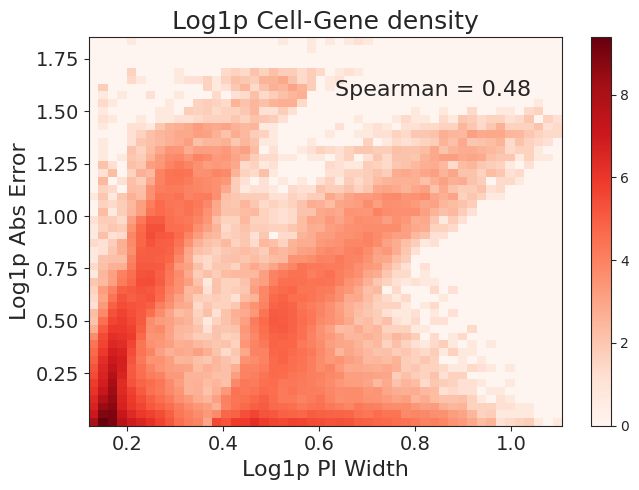

In [39]:
# compute correlations
rho, p = spearmanr(np.log1p(all_uppers-all_lowers)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)],
            np.log1p(all_maes)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)])
r, p = pearsonr(np.log1p(all_uppers-all_lowers)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)],
            np.log1p(all_maes)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)])
print(rho)
print(r)

# make 2D heatmap plot
plt.figure(figsize=(7,5))
heatmap, xedges, yedges = np.histogram2d(
    np.log1p(all_uppers-all_lowers)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)],
            np.log1p(all_maes)[(all_predicteds>0)&np.isfinite(all_predicteds)&~np.isnan(all_uppers-all_lowers)],
            bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
plt.imshow(np.log1p(heatmap).T, extent=extent, origin='lower', cmap='Reds', aspect='auto')
plt.annotate("Spearman = "+str(round(rho,2)), (0.52,0.85), xycoords="axes fraction", fontsize=16)
plt.colorbar()
plt.title("Log1p Cell-Gene density",fontsize=18)
plt.xlabel("Log1p PI Width", fontsize=16)
plt.ylabel("Log1p Abs Error", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig('../../plots/mechanism/TISSUE_CI_vs_AE_67.pdf', dpi=300, bbox_inches='tight')
plt.show()

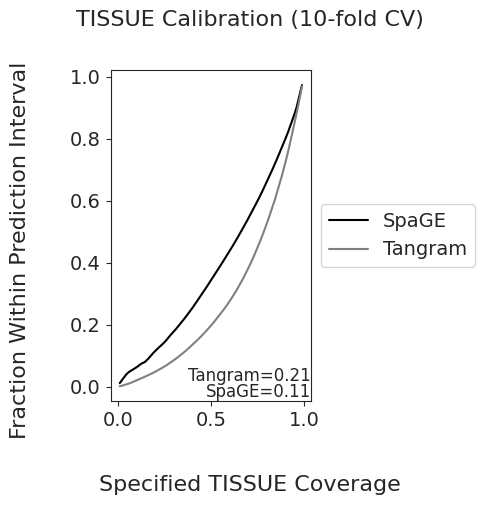

In [54]:
# all in one AVG calibration plot
dataset_names = ["SVZ"]
keys = ["spage", "tangram"]
colors = ["k", "0.5"]

fig, axs = plt.subplots(nrows=1, ncols=len(dataset_names), sharex=True, sharey=True, figsize=(5, 5))
for i, dataset_name in enumerate(dataset_names):
    
    # load in pickle object with dictionary of calibration results
    pickleFile = open("SCPI_k4_k1/"+dataset_name+"_conformal_dict.pkl", 'rb')
    res_dict = pickle.load(pickleFile)
    
    # plot calibration curve from dict results + compute calibration error
    for ki, key in enumerate(keys):
        axs.plot(res_dict[key]['1-alpha'], res_dict[key]['test'], linewidth=1.5, label=method_mapper[key], color=colors[ki])
        error = round(measure_calibration_error(res_dict, key),2)
        axs.annotate(method_mapper[key]+"="+str(error), xy=(1, 0+(ki*0.05)), xycoords='axes fraction', fontsize=12, horizontalalignment='right', verticalalignment='bottom')
    
    #axs.set_title(dataset_mapper[dataset_name], fontsize=14)
    axs.tick_params(axis='both', which='major', labelsize=14)
    axs.tick_params(axis='both', which='minor', labelsize=14)
    
fig.suptitle("TISSUE Calibration (10-fold CV)", fontsize=16)
fig.supxlabel("Specified TISSUE Coverage", fontsize=16)
fig.supylabel("Fraction Within Prediction Interval", fontsize=16)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14, ncol=1)
plt.tight_layout(pad=1.8)
plt.savefig('../../plots/mechanism/TISSUE_calibration_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()